<h2 style="text-align: center;"> EJERCICIO DEBER ANÁLISIS DE DATOS CLÍNICOS PARA LA DETECCIÓN DE ENFERMEDADES CARDÍACAS </h2>

<img src="img/ITQ.jpg" width="700">

**Nombre:** *Sebastian Sampedro* <br>
**Fecha:** *6/5/2026* <br>
**Link Github:** "https://github.com/sdsampedro-byte/Python2026ML"

# Práctica Académica
## Normalización y Estandarización de Datos en Inteligencia Artificial
# Análisis y aplicación de técnicas de normalización y estandarización en conjunto de datos para modelos de aprendizaje automático
### Enunciado
En la actualidad, las enfermedades cardiovasculares representan una de las principales causas de mortalidad a nivel mundial, lo que ha impulsado el uso de técnicas de análisis de datos e inteligencia artificial para apoyar en su detección temprana.<br>

Un centro médico especializado ha recopilado un conjunto de datos clínicos de pacientes, el cual incluye variables como edad, presión arterial, niveles de colesterol, frecuencia cardíaca máxima y otros indicadores relevantes para la salud cardiovascular. Sin embargo, durante el análisis preliminar, se ha identificado que los datos presentan diferencias significativas en sus escalas y rangos, lo que podría afectar negativamente el desempeño de los modelos predictivos.<br>

Como parte del equipo de analistas de datos, se le ha asignado la tarea de realizar un proceso de preprocesamiento de los datos, específicamente aplicando técnicas de normalización y estandarización, con el objetivo de preparar la información para su uso en modelos de aprendizaje automático orientados a la clasificación de pacientes con riesgo de enfermedad cardíaca.<br>
El propósito de esta actividad es comprender cómo las diferencias en la escala de los datos pueden influir en los resultados y cómo las técnicas de escalado permiten mejorar la calidad del análisis y la precisión de los modelos.<br>
### Objetivo General
Aplicar técnicas de normalización y estandarización a un conjunto de datos clínicos relacionados con enfermedades cardíacas, con el fin de analizar su impacto en la preparación de datos y en el rendimiento de modelos de aprendizaje automático.<br>
### Objetivos especificos
* Identificar diferencias de escala entre variables numércias.
* Aplicar técnicas de normalización (Min-Max)
* Aplicar técnicas de estandarización (Z-score)
* Analizar la importancia del preprocesaminto en modelos de IA
### Antecedentes /Fundamentación teórica
En el contexto del aprendizaje automático, los algoritmos suelen verse afectados por la escala de los datos. Variables con valores grandes pueden dominar el comportamiento del modelo, generando sesgos y resultados pocos conficables.<br>
Para mitigar este problema, se emplea técnicas como:
* **Normalización**: transforma los datos a un rango especifico (generalmente[0,1])
* **Estandarización**: ajusta los datos para que tengan mdia 0 y desviación estandar 1.
Estas técnicas son fundamentales en algoritmos como:
* KNN
* Regresión logística
* Redes neuronales
### Resultado esperado
El estudiante será capaz de reconocer la importancia del escalado de datos en contextos reales de salud, comprendiendo que un adecuado preprocesamiento es fundamental para el desarrollo de modelos predictivos confiables en inteligencia artificial.
## Conjunto de datos  utilizar
DataSet 1: <a href="https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset">Conjunto de datos de enfermedades cardiacas</a>

In [1]:
# Importacion de librerias 
import pandas as pd
import numpy as np
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [2]:
# Configuramos el entorno de descarga
import os
os.environ['KAGGLE_CONFIG_DIR']="C:/Users/Sebas/.kaggle"

In [4]:
# Descargar el dataset 
!kaggle datasets download -d johnsmith88/heart-disease-dataset

Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
License(s): unknown
heart-disease-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
# Descompriminos el archivo 
import zipfile

# Descomprime el archivo descargado
with zipfile.ZipFile('heart-disease-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('heart_disease_data')

In [8]:
# Cargamos el conjunto de datos 
df = pd.read_csv('heart_disease_data/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [10]:
# Separamos los datos de entrada con nuestra variable objetivo 
X = df.drop(columns=['target'])
y = df['target']
print(y)

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64


In [14]:
# Mostramos los detalles de nuesto dataset
df.info()
#Verificamos si tenemos datos nulos si lo tenemos lo sumamos 
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [11]:
# Exploramos o generamos un analis exploratorio del conjutno de datos
X.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000


### Conclusión
Al observar las estadísticas del dataset de salud cardíaca, se nota claramente que cada variable tiene rangos y magnitudes muy distintas. Por ejemplo:

- **chol (Colesterol):** tiene valores que pueden superar los 240 o incluso llegar a 500, lo que representa un rango numérico muy amplio.

- **oldpeak:** en cambio, varía en un rango pequeño de aproximadamente 0.0 a 6.2.

- **age (Edad):** se mueve en un rango intermedio, generalmente entre 29 y 77 años.

Esto confirma que las variables no están en la misma escala.

### ¿Qué significa?
Al trabajar con modelos matemáticos (como KNN o Regresión Logística), las diferencias de magnitud generan problemas:

- **Dominancia de números grandes:** Variables como el colesterol (chol) "pesarán más" simplemente por tener valores numéricos más altos.

- **Sesgo en la importancia:** El modelo podría ignorar variables cruciales como oldpeak o fbs solo porque sus números son pequeños, asumiendo erróneamente que tienen menos impacto en el riesgo cardíaco. A esto lo llamamos sesgo por escala.

Para garantizar que el modelo sea justo y trate a todas las características con la misma importancia, aplicamos:

- **Normalización:** Para llevar los datos a un rango de [0, 1].

- **Estandarización:** Para que los datos tengan media 0 y desviación estándar 1.

Esto permite que variables con diferentes unidades (años, mg/dl, mm Hg) sean comparables entre sí.

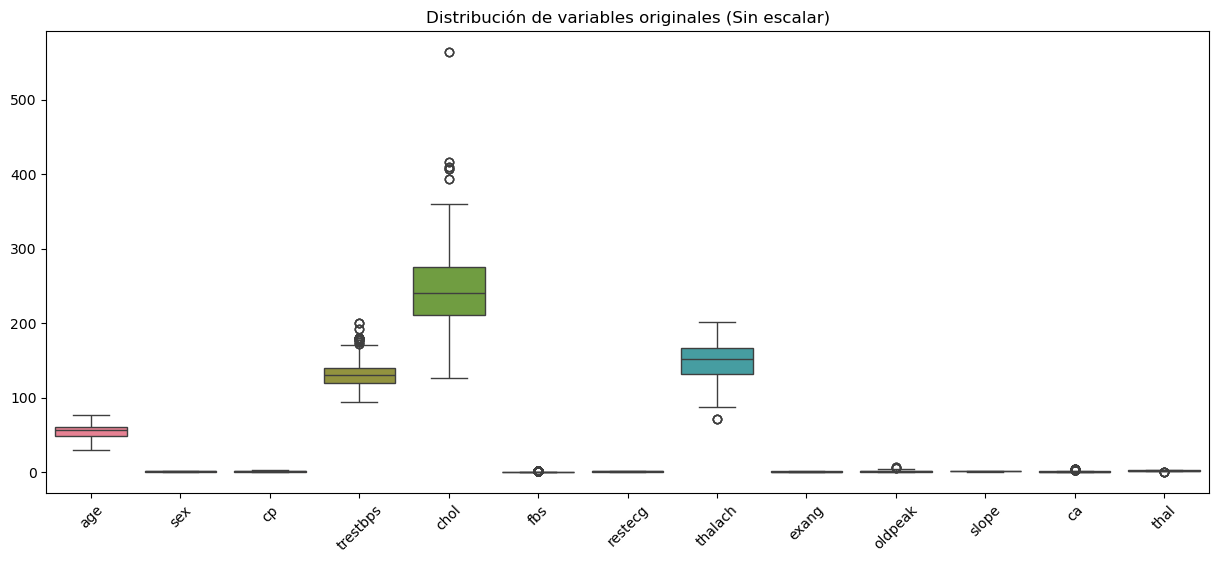

In [17]:
# Creamos el gráfico de caja para todas las variables
plt.figure(figsize=(15, 6))
sns.boxplot(data=X)
plt.title("Distribución de variables originales (Sin escalar)")
plt.xticks(rotation=45)
plt.show()

### Análisis de la gráfica:
- **Dominancia de chol (Colesterol):** Se observa que la caja verde de chol está altísima (alrededor de 250) en comparación con todas las demás. Si se entrena un modelo así, el algoritmo pensará que el colesterol es "miles de veces más importante" que variables como oldpeak o ca solo porque sus números son más grandes.

- **Variables invisibles:** Columnas como sex, cp, fbs, exang, slope, ca y thal aparecen como líneas planas en el suelo (cerca del cero). Esto sucede porque su rango es tan pequeño (0 a 3) que, comparado con los 500 del colesterol, desaparecen visualmente.

- **Outliers (Valores atípicos):** Los círculos sobre chol y trestbps muestran que hay personas con valores extremadamente altos. La estandarización ayudará a que estos valores no desvíen tanto al modelo.

In [18]:
# Normalizamos el conjunto de datos 
normalizer = preprocessing.MinMaxScaler()
X_norm=normalizer.fit_transform(X)
X_norm = pd.DataFrame(X_norm, columns=X.columns)
X_norm.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.479167,1.0,0.0,0.292453,0.196347,0.0,0.5,0.740458,0.0,0.161290,1.0,0.50,1.000000
1,0.500000,1.0,0.0,0.433962,0.175799,1.0,0.0,0.641221,1.0,0.500000,0.0,0.00,1.000000
2,0.854167,1.0,0.0,0.481132,0.109589,0.0,0.5,0.412214,1.0,0.419355,0.0,0.00,1.000000
3,0.666667,1.0,0.0,0.509434,0.175799,0.0,0.5,0.687023,0.0,0.000000,1.0,0.25,1.000000
4,0.687500,0.0,0.0,0.415094,0.383562,1.0,0.5,0.267176,0.0,0.306452,0.5,0.75,0.666667


In [19]:
# EDA del dataset normalizado 
X_norm.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,0.529878,0.695610,0.314146,0.354827,0.273973,0.149268,0.264878,0.596291,0.336585,0.172825,0.692683,0.188537,0.774634
std,0.189006,0.460373,0.343214,0.165252,0.117791,0.356527,0.263939,0.175616,0.472772,0.189525,0.308878,0.257699,0.206887
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.395833,0.000000,0.000000,0.245283,0.194064,0.000000,0.000000,0.465649,0.000000,0.000000,0.500000,0.000000,0.666667
50%,0.562500,1.000000,0.333333,0.339623,0.260274,0.000000,0.500000,0.618321,0.000000,0.129032,0.500000,0.000000,0.666667
75%,0.666667,1.000000,0.666667,0.433962,0.340183,0.000000,0.500000,0.725191,1.000000,0.290323,1.000000,0.250000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [20]:
# Estandarización 
standarizer = preprocessing.StandardScaler()
# Estandarizamos los datos
X_std=standarizer.fit_transform(X)
X_std= pd.DataFrame(X_std, columns=X.columns)
X_std.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.268437,0.661504,-0.915755,-0.377636,-0.659332,-0.418878,0.891255,0.821321,-0.712287,-0.060888,0.995433,1.209221,1.089852
1,-0.158157,0.661504,-0.915755,0.479107,-0.833861,2.387330,-1.004049,0.255968,1.403928,1.727137,-2.243675,-0.731971,1.089852
2,1.716595,0.661504,-0.915755,0.764688,-1.396233,-0.418878,0.891255,-1.048692,1.403928,1.301417,-2.243675,-0.731971,1.089852
3,0.724079,0.661504,-0.915755,0.936037,-0.833861,-0.418878,0.891255,0.516900,-0.712287,-0.912329,0.995433,0.238625,1.089852
4,0.834359,-1.511706,-0.915755,0.364875,0.930822,2.387330,0.891255,-1.874977,-0.712287,0.705408,-0.624121,2.179817,-0.522122


In [22]:
# EDA del dataset estandarizado 
X_std.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,1.025000e+03,1.025000e+03,1.025000e+03,1.025000e+03,1.025000e+03,1.025000e+03,1.025000e+03,1.025000e+03,1.025000e+03,1.025000e+03,1.025000e+03,1.025000e+03,1.025000e+03
mean,-3.431402e-16,1.802352e-16,5.545699e-17,-7.036106e-16,-3.466062e-18,-4.159275e-17,-8.318549e-17,-4.332578e-16,-7.625337e-17,-2.426243e-16,1.854343e-16,1.819683e-17,2.530225e-16
std,1.000488e+00,1.000488e+00,1.000488e+00,1.000488e+00,1.000488e+00,1.000488e+00,1.000488e+00,1.000488e+00,1.000488e+00,1.000488e+00,1.000488e+00,1.000488e+00,1.000488e+00
min,-2.804866e+00,-1.511706e+00,-9.157554e-01,-2.148237e+00,-2.327054e+00,-4.188779e-01,-1.004049e+00,-3.397080e+00,-7.122871e-01,-9.123291e-01,-2.243675e+00,-7.319715e-01,-3.746070e+00
25%,-7.095548e-01,-1.511706e+00,-9.157554e-01,-6.632165e-01,-6.787242e-01,-4.188779e-01,-1.004049e+00,-7.442713e-01,-7.122871e-01,-9.123291e-01,-6.241209e-01,-7.319715e-01,-5.221223e-01
50%,1.726817e-01,6.615041e-01,5.593123e-02,-9.205458e-02,-1.163527e-01,-4.188779e-01,8.912549e-01,1.255019e-01,-7.122871e-01,-2.311765e-01,-6.241209e-01,-7.319715e-01,-5.221223e-01
75%,7.240794e-01,6.615041e-01,1.027618e+00,4.791073e-01,5.623715e-01,-4.188779e-01,8.912549e-01,7.343432e-01,1.403928e+00,6.202642e-01,9.954333e-01,2.386246e-01,1.089852e+00
max,2.488552e+00,6.615041e-01,1.999305e+00,3.906079e+00,6.166694e+00,2.387330e+00,2.786558e+00,2.299935e+00,1.403928e+00,4.366603e+00,9.954333e-01,3.150413e+00,1.089852e+00


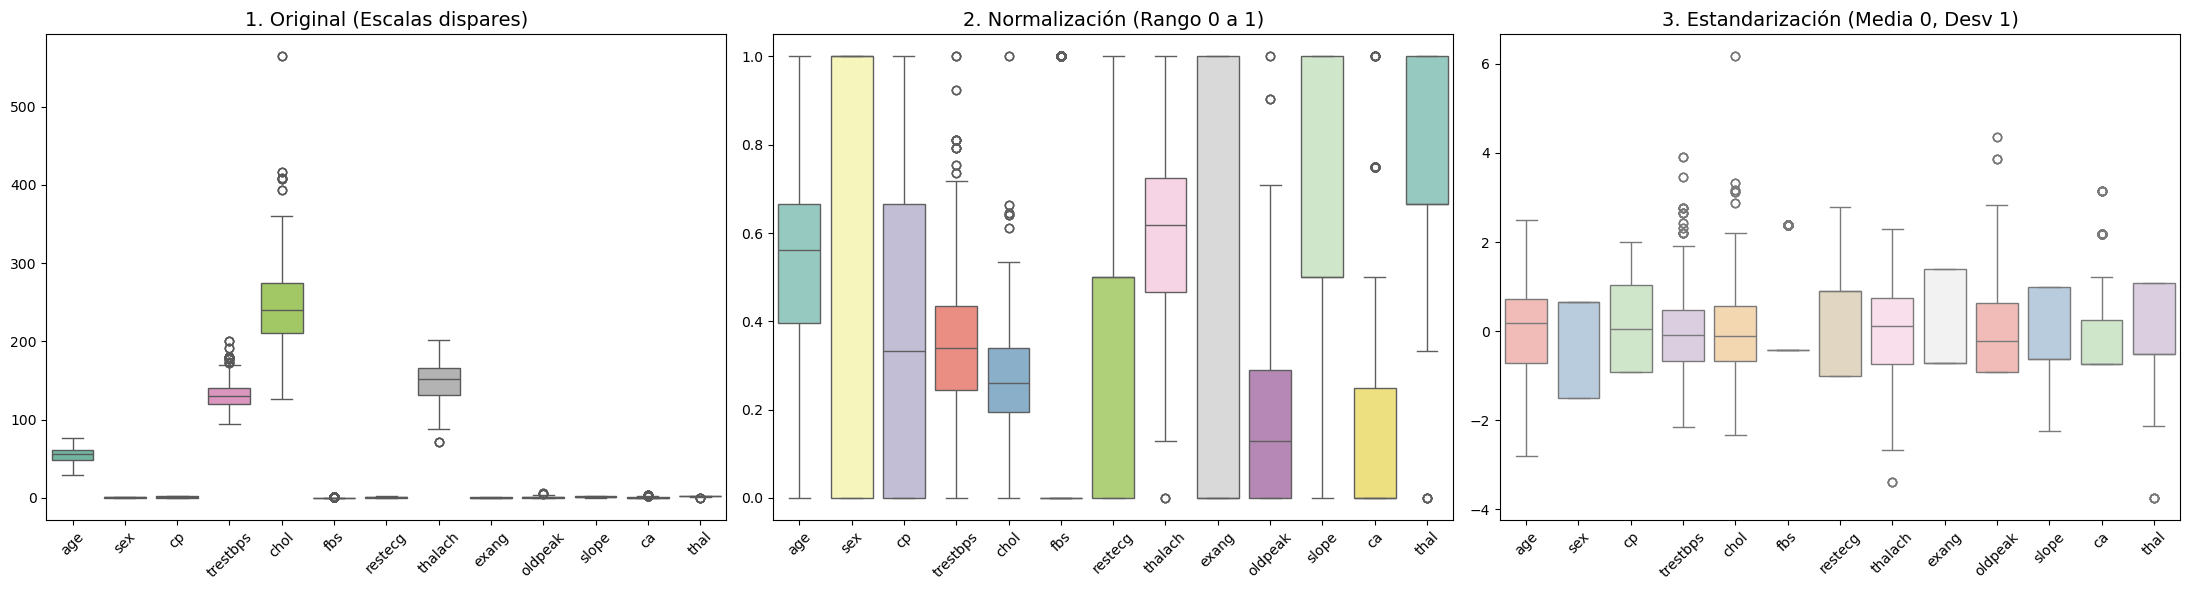

In [24]:
# COMPARATIVA VISUAL (ORIGINAL - NORMALIZACIÓN - ESTANDARIZACIÓN)
# Configuramos el lienzo para 3 gráficos alineados
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Gráfico 1: Datos Originales
sns.boxplot(data=X, ax=axes[0], palette="Set2")
axes[0].set_title("1. Original (Escalas dispares)", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Normalización (Min-Max)
sns.boxplot(data=X_norm, ax=axes[1], palette="Set3")
axes[1].set_title("2. Normalización (Rango 0 a 1)", fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

# Gráfico 3: Estandarización (StandardScaler)
sns.boxplot(data=X_std, ax=axes[2], palette="Pastel1")
axes[2].set_title("3. Estandarización (Media 0, Desv 1)", fontsize=14)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### **CONCLUSIÓN**
Al comparar ambos métodos, se observa que la Normalización es útil para mantener los datos en un rango cerrado de 0 a 1, facilitando algoritmos basados en distancias como KNN. Sin embargo, la Estandarización es más reveladora para este dataset de salud, ya que permite identificar claramente qué tan lejos de la media se encuentran los pacientes (outliers) en variables críticas como el colesterol o la presión arterial, manteniendo una distribución con media 0 y varianza 1.

### **IMPORTANCIA DEL PROCESAMIENTO EN MODELOS DE IA**
El procesamiento de datos no es solo un paso previo, sino la columna vertebral que determina si un modelo de Inteligencia Artificial será preciso o presentará sesgos insalvables.

**1. Eliminación del Sesgo de Magnitud**
Como se observa en las gráficas de Boxplot, variables como el colesterol (chol) tienen valores hasta 500, mientras que otras como oldpeak apenas llegan a 6.

**Importancia:** Sin procesamiento, el modelo (especialmente KNN, SVM o Regresión) interpretará matemáticamente que el colesterol es 80 veces más importante que las demás variables solo por su tamaño numérico. El escalado "nivela el campo de juego" para que todas las características influyan por su relevancia real y no por su unidad de medida.

**2. Aceleración de la Convergencia**
Muchos modelos de IA utilizan un proceso llamado Descenso de Gradiente para aprender.

**Importancia:** Cuando los datos están en escalas muy diferentes, el algoritmo tarda mucho más en encontrar el "camino óptimo" (mínimo global). Al estandarizar (media 0 y varianza 1), el modelo converge hacia la solución de forma mucho más rápida y eficiente, ahorrando tiempo de cómputo y recursos.

**3. Gestión de Outliers (Valores Atípicos)**
En datos médicos, los valores extremos son comunes pero peligrosos.

**Importancia:** El procesamiento permite que el modelo identifique casos atípicos sin que estos distorsionen por completo el aprendizaje de la población general. Si no se procesan, un solo paciente con un dato extremo podría desviar toda la frontera de decisión del modelo.

**4. Estabilidad Matemática**
Ciertos algoritmos de IA son sensibles a las distribuciones de los datos.

**Importancia:** Al aplicar Normalización o Estandarización, transformamos los datos en una forma que los algoritmos "entienden" mejor. Esto evita errores numéricos y asegura que el modelo sea estable, produciendo resultados similares cuando se le presentan datos nuevos.